In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

os.chdir("../src")
os.getcwd()

from simulator.gca import Maxflow2GCA

%load_ext autoreload
%autoreload 2

In [56]:
def graph_balances_and_credit_limits(G):
    n = G.number_of_nodes()
    balances = np.zeros(n)
    limits = np.zeros(n)

    for node, dd in G.nodes(data=True):
        balances[node] = dd["state"].balance
        limits[node] = dd["state"].credit_limit

    return balances, limits


def plot_balances_and_credit_limits(balances, limits):
    assert len(balances) == len(limits)
    x = np.arange(len(balances))
    plt.bar(x, balances, label='Available balances')
    plt.bar(x, limits, bottom=balances, label='Credit limits')
    plt.legend()
    plt.show()

In [59]:
def create_simulation(graph):
    
    num_edges = graph.number_of_edges()
    capacities = list(np.random.randint(1, 10000, num_edges))
    balances = {node: np.random.randint(1, 100000) for node in graph.nodes}
    
    for edge in graph.edges:
        graph.edges[edge]["capacity"] = capacities.pop()
    
    gca = Maxflow2GCA(graph, balance_distribution=balances)
    records = gca.run_simulation(10)
    return records

In [60]:
# Create a Watts-Strogatz graph
n = 1000  # number of nodes
k = 10    # each node is connected to k nearest neighbors in ring topology
p = 0.1   # the probability of rewiring each edge

records = []

graph_1 = nx.barabasi_albert_graph(n, 2, seed=42)
records.append({
    "title": "barabasi_albert_graph",
    "graph": graph_1,
    "records": create_simulation(graph_1)
})


graph_2 = nx.watts_strogatz_graph(n, k, p, seed=42)
records.append({
    "title": "watts_strogatz_graph",
    "graph": graph_2,
    "records": create_simulation(graph_2)
})



                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations:   0%|          | 0/1 [00:00<?, ?it/s]

Execution Method: single_proc_exec


Flattening results:   0%|          | 0/11 [00:00<?, ?it/s]

Total execution time: 0.65s

                  ___________    ____
  ________ __ ___/ / ____/   |  / __ \
 / ___/ __` / __  / /   / /| | / / / /
/ /__/ /_/ / /_/ / /___/ ___ |/ /_/ /
\___/\__,_/\__,_/\____/_/  |_/_____/
by cadCAD

cadCAD Version: 0.5.3
Execution Mode: single_proc
Simulation Dimensions:
Entire Simulation: (Models, Unique Timesteps, Params, Total Runs, Sub-States) = (1, 10, 0, 1, 1)
     Simulation 0: (Timesteps, Params, Runs, Sub-States) = (10, 0, 1, 1)


Initializing configurations:   0%|          | 0/1 [00:00<?, ?it/s]

Execution Method: single_proc_exec


Flattening results:   0%|          | 0/11 [00:00<?, ?it/s]

Total execution time: 0.66s


KeyError: 'title'

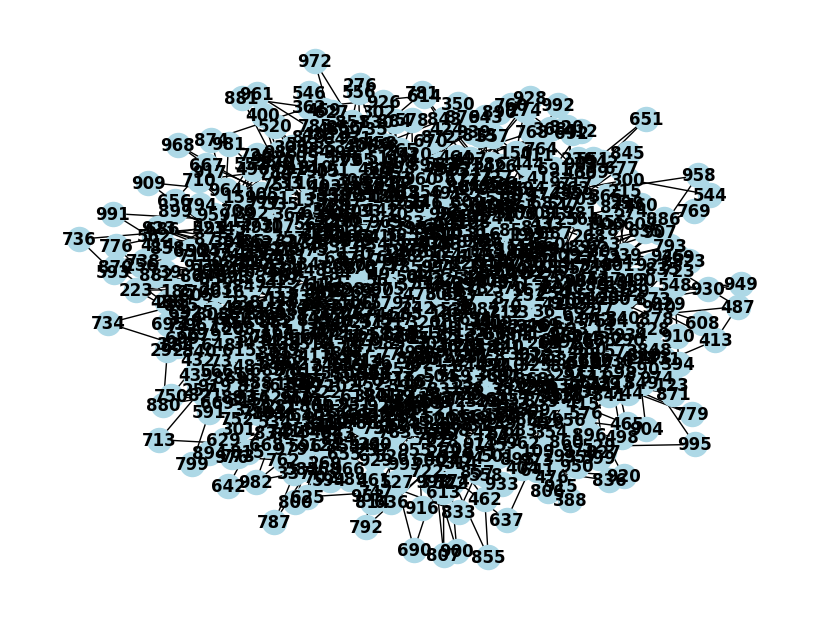

In [61]:

def plot_graph(title, record):
    graph = record['graph']
    plt.figure(figsize=(8, 6))  # Create a new figure for each graph
    nx.draw(graph, with_labels=True, node_color='lightblue', font_weight='bold')
    plt.title(f"{record['title']} at timestep {record['timestep']} (Run {record['run']}, Substep {record['substep']})")
    plt.show()

# Plot each record
for i, record_state in enumerate(records):
    for steps in record_state['records']:
        for step in steps:
            plot_graph(step)
            #g = step['graph']
            #print(record)
    